# Monitor Drift (Experiment 4) -- EDA

Visualizes the output of `run_monitor_drift_experiment`
(`thesis.experiments.monitor_drift`): for each shortlisted config, a
schema+model is mined/fit once on window 0's train split (same design as
`temporal_decay.py` -- W_src is always the first window) and frozen. For
symbolic configs, a deployment-scoped `DynamicSchema` (Vk) is built from
that same mining pass. The frozen schema/model/Vk are then walked forward
one window at a time from `h=0` (W_src's own held-out test split) to
`h=n_windows-1`, and at every horizon the drift monitor
(`thesis.monitor.monitor.run_monitor_window`) runs against the frozen Vk
over that horizon's raw incoming alert groups.

This is **observe-only**: the monitor's action (`NO_ACTION`/`SOFT_ALERT`/
`RETRAIN_ONLY`/`REMINE_AND_RETRAIN`) is recorded but nothing is ever
actually re-mined or retrained. `baseline` configs have no `DynamicSchema`
(nothing was mined), so the monitor never runs for them -- their rows carry
no monitor columns.

Loads four artifacts: `per_horizon_results.csv` (model decay metrics +
per-horizon monitor summary), `decay_summary.csv` (reused unmodified from
`temporal_decay.py`), `monitor_signals.csv` (dense long format -- every
predicate/rule signal at every horizon, elevated or not), and
`monitor_alarms.csv` (the `elevated == True` subset of `monitor_signals.csv`
-- the "when did the monitor fire, and why" log).

In [1]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt

from thesis.monitor.signals import (
    CALIBRATION_DRIFT_THRESHOLD,
    PSI_ELEVATED_THRESHOLD,
    PSI_SIGNIFICANT_THRESHOLD,
)
from thesis.paths import ARTIFACTS_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Thresholds

Edit and re-run below -- nothing past this cell needs to change.

Action colors/markers follow a status palette (escalating severity), not an
arbitrary categorical one: `SOFT_ALERT` (warning) -> `RETRAIN_ONLY` (serious)
-> `REMINE_AND_RETRAIN` (critical). Each action is also encoded by marker
shape, not color alone.

In [2]:
SCENARIO = "cscas"
RUN_ID = None  # None -> latest run dir for SCENARIO

PRIMARY_METRIC = "auc"  # which metric to draw as the main degradation curve
SOURCE_COLOR = "#CC3311"  # h=0 (W_src's own held-out test split)
LINE_COLOR = "#4477AA"

# Status palette (escalating severity), never reused for anything else.
ACTION_COLORS = {
    "SOFT_ALERT": "#fab219",       # warning
    "RETRAIN_ONLY": "#ec835a",     # serious
    "REMINE_AND_RETRAIN": "#d03b3b",  # critical
}
ACTION_MARKERS = {
    "SOFT_ALERT": "^",
    "RETRAIN_ONLY": "s",
    "REMINE_AND_RETRAIN": "X",
}

# Which config's alarm detail to print in section 4 -- see the printed
# config list in that section, then set this to its row index.
CONFIG_SELECT = 0

In [3]:
run_dir_base = ARTIFACTS_DIR / "experiments" / "monitor_drift" / SCENARIO
# Only consider run directories -- run_dir_base also holds
# _derived_shortlist.csv (written by --structural-configs runs), and
# sorting unfiltered would pick that file as "latest" since "_" sorts after
# digits, then crash trying to treat it as a directory.
run_dirs = [p for p in run_dir_base.iterdir() if p.is_dir()]
run_dir = run_dir_base / RUN_ID if RUN_ID else sorted(run_dirs)[-1]

per_horizon = pd.read_csv(run_dir / "per_horizon_results.csv")
decay_summary = pd.read_csv(run_dir / "decay_summary.csv")
monitor_signals = pd.read_csv(run_dir / "monitor_signals.csv")
monitor_alarms = pd.read_csv(run_dir / "monitor_alarms.csv")

print(f"Loaded from {run_dir}")
print(f"per_horizon: {len(per_horizon)} rows, monitor_signals: {len(monitor_signals)} rows, "
      f"monitor_alarms: {len(monitor_alarms)} rows")

Loaded from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/monitor_drift/cscas/20260713_235944
per_horizon: 70 rows, monitor_signals: 2010 rows, monitor_alarms: 90 rows


## 1. Degradation curves + monitor alarms

One small-multiple per config: metric vs. horizon (window index), walking
forward from window 0 to the end of the timeline -- same layout as
`temporal_decay_eda.ipynb`'s degradation curves, with monitor alarms
overlaid: a marker at every horizon where the monitor's action was not
`NO_ACTION`, shaped/colored by which action fired. `h=0` (W_src's own
held-out test split) is starred; every other point is a fully external
window. `baseline` configs never carry an alarm marker (no `DynamicSchema`
was mined for them).

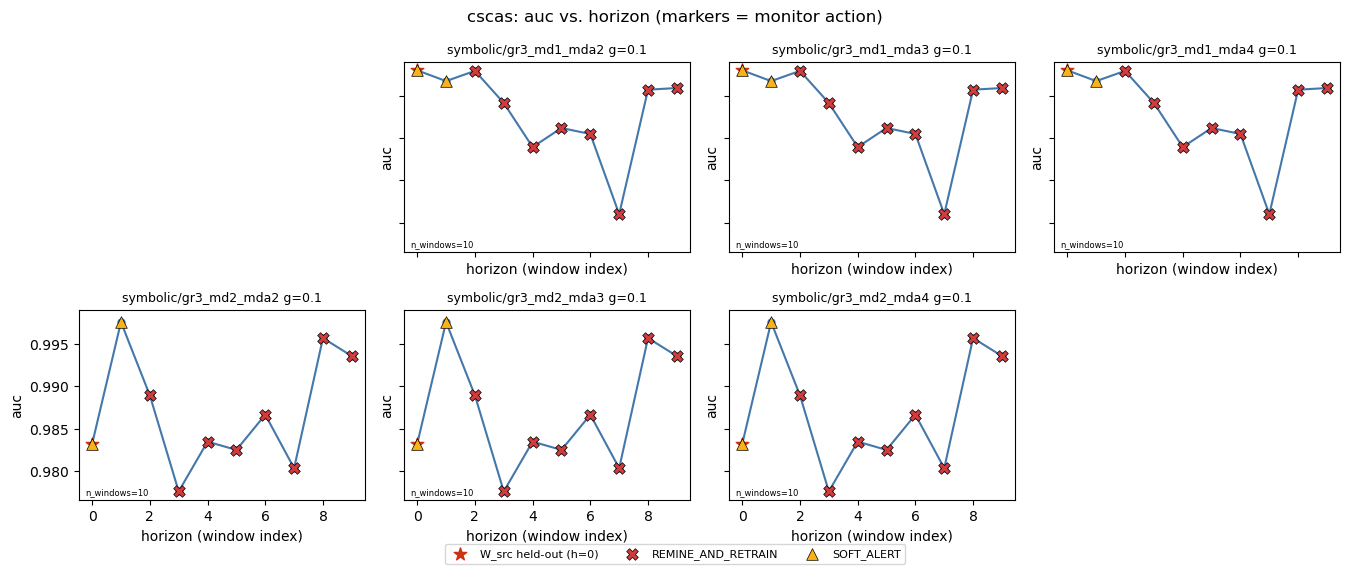

In [4]:
CONFIG_COLS = ["feature_set", "mining_setting", "granularity", "model"]


def config_label(row) -> str:
    return f"{row['feature_set']}/{row['mining_setting']} g={row['granularity']:g}"


def ordered_configs(df: pd.DataFrame) -> pd.DataFrame:
    # Ordered by granularity (not first-appearance) so configs at the same
    # granularity land next to each other for visibility.
    return (
        df[CONFIG_COLS].drop_duplicates()
        .sort_values(["granularity", "feature_set", "mining_setting"])
        .reset_index(drop=True)
    )


def plot_degradation_curves_with_alarms(metric: str, title: str) -> None:
    configs = ordered_configs(per_horizon)
    n = len(configs)
    ncols = 4
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.4 * ncols, 2.8 * nrows), squeeze=False,
        sharex=True, sharey=True,
    )

    for i, cfg_row in configs.iterrows():
        ax = axes[i // ncols][i % ncols]
        mask = (per_horizon[CONFIG_COLS] == cfg_row).all(axis=1)
        sub = per_horizon[mask].sort_values("horizon_window_index")
        if sub.empty or metric not in sub.columns:
            ax.axis("off")
            continue

        source = sub[sub["is_source_window"]]
        rest = sub[~sub["is_source_window"]]

        ax.plot(sub["horizon_window_index"], sub[metric], "-", color=LINE_COLOR, zorder=1)
        ax.scatter(rest["horizon_window_index"], rest[metric], color=LINE_COLOR, zorder=3, s=25)
        if not source.empty:
            ax.scatter(
                source["horizon_window_index"], source[metric],
                color=SOURCE_COLOR, marker="*", s=90, zorder=5,
                label="W_src held-out (h=0)",
            )

        alarmed = sub[sub["action"].notna() & (sub["action"] != "NO_ACTION")]
        for action, group in alarmed.groupby("action"):
            ax.scatter(
                group["horizon_window_index"], group[metric],
                color=ACTION_COLORS.get(action, "#898781"),
                marker=ACTION_MARKERS.get(action, "x"),
                s=70, zorder=6, edgecolors="black", linewidths=0.5,
                label=action,
            )

        ax.set_title(config_label(cfg_row), fontsize=9)
        ax.text(
            0.02, 0.02, f"n_windows={int(sub['n_windows'].iloc[0])}",
            transform=ax.transAxes, fontsize=6, va="bottom",
        )
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel(metric)

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    handles, labels = [], []
    for ax_row in axes:
        for ax in ax_row:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels:
                    handles.append(hh)
                    labels.append(ll)
    if handles:
        fig.legend(
            handles, labels, loc="lower center", ncol=min(len(labels), 5),
            bbox_to_anchor=(0.5, -0.02), fontsize=8,
        )

    fig.suptitle(title)
    fig.tight_layout()


plot_degradation_curves_with_alarms(
    PRIMARY_METRIC, f"{SCENARIO}: {PRIMARY_METRIC} vs. horizon (markers = monitor action)"
)

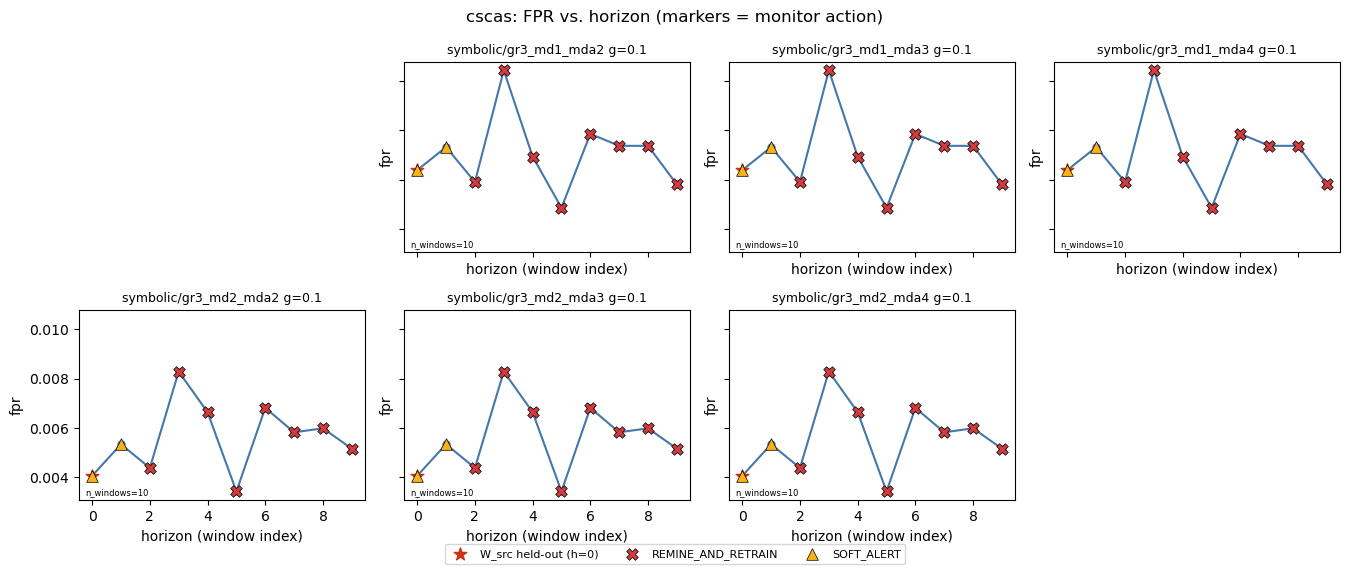

In [5]:
plot_degradation_curves_with_alarms(
    "fpr", f"{SCENARIO}: FPR vs. horizon (markers = monitor action)"
)

## 2. Decay summary

Score/FPR at `h=0` (W_src's own held-out test split) vs. the last horizon
actually reached (`h_max`), and their difference -- reused unmodified from
`temporal_decay.py::_build_decay_summary`. Purely about model performance;
doesn't reference the monitor at all.

In [6]:
sort_col = f"decay_rate_{PRIMARY_METRIC}"
decay_summary.sort_values(sort_col, ascending=False) if sort_col in decay_summary.columns else decay_summary

,feature_set,mining_setting,granularity,model,h_max,auc_at_h0,auc_at_h9,decay_rate_auc,f1_at_h0,f1_at_h9,decay_rate_f1,accuracy_at_h0,accuracy_at_h9,decay_rate_accuracy,precision_at_h0,precision_at_h9,decay_rate_precision,recall_at_h0,recall_at_h9,decay_rate_recall,fpr_at_h0,fpr_at_h9,fpr_drift
0,baseline,NaN,0.1,logreg,9,0.998037,0.995840,0.002197,0.717557,0.804533,-0.086975,0.992929,0.993572,-0.000643,0.569697,0.699507,-0.129810,0.969072,0.946667,0.022405,0.006848,0.005764,-0.001084
1,symbolic,gr3_md1_mda2,0.1,logreg,9,0.998082,0.995982,0.002101,0.732039,0.803742,-0.071704,0.993407,0.993536,-0.000129,0.587227,0.698035,-0.110807,0.971649,0.947179,0.024470,0.006390,0.005807,-0.000583
2,symbolic,gr3_md1_mda3,0.1,logreg,9,0.998082,0.995982,0.002101,0.732039,0.803742,-0.071704,0.993407,0.993536,-0.000129,0.587227,0.698035,-0.110807,0.971649,0.947179,0.024470,0.006390,0.005807,-0.000583
3,symbolic,gr3_md1_mda4,0.1,logreg,9,0.998082,0.995982,0.002101,0.732039,0.803742,-0.071704,0.993407,0.993536,-0.000129,0.587227,0.698035,-0.110807,0.971649,0.947179,0.024470,0.006390,0.005807,-0.000583
4,symbolic,gr3_md2_mda2,0.1,logreg,9,0.983185,0.993608,-0.010423,0.804301,0.819796,-0.015495,0.995652,0.994181,0.001471,0.690037,0.722613,-0.032577,0.963918,0.947179,0.016738,0.004051,0.005153,0.001102
5,symbolic,gr3_md2_mda3,0.1,logreg,9,0.983185,0.993608,-0.010423,0.804301,0.819796,-0.015495,0.995652,0.994181,0.001471,0.690037,0.722613,-0.032577,0.963918,0.947179,0.016738,0.004051,0.005153,0.001102
6,symbolic,gr3_md2_mda4,0.1,logreg,9,0.983185,0.993608,-0.010423,0.804301,0.819796,-0.015495,0.995652,0.994181,0.001471,0.690037,0.722613,-0.032577,0.963918,0.947179,0.016738,0.004051,0.005153,0.001102


## 3. Signal buildup below threshold

For each symbolic config: the maximum PSI across all single predicates
(Signal 1) and the maximum calibration drift across all compound rules
(Signal 2), per horizon -- shows drift building up even *before* it crosses
the elevated line. Reference lines are drawn at the actual threshold
constants imported from `thesis.monitor.signals`, so this plot can never
drift out of sync with the real monitor thresholds. `baseline` configs are
absent (no `DynamicSchema`, no signals).

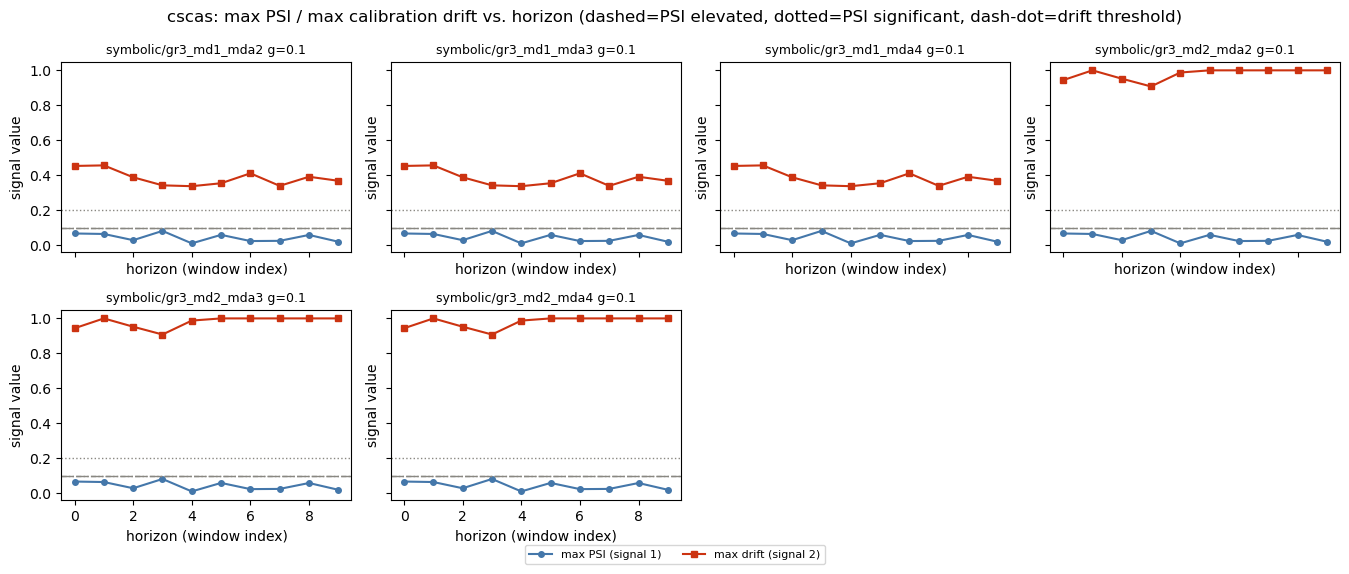

In [7]:
def plot_signal_buildup() -> None:
    if monitor_signals.empty:
        print("No monitor signals recorded (no symbolic configs ran, or no horizons produced signals).")
        return

    configs = ordered_configs(monitor_signals)
    n = len(configs)
    ncols = 4
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.4 * ncols, 2.8 * nrows), squeeze=False,
        sharex=True, sharey=True,
    )

    for i, cfg_row in configs.iterrows():
        ax = axes[i // ncols][i % ncols]
        mask = (monitor_signals[CONFIG_COLS] == cfg_row).all(axis=1)
        sub = monitor_signals[mask]

        sig1 = (
            sub[sub["signal_type"] == "signal_1"]
            .groupby("horizon_window_index")["metric_value"].max()
        )
        sig2 = (
            sub[sub["signal_type"] == "signal_2"]
            .groupby("horizon_window_index")["metric_value"].max()
        )

        ax.plot(sig1.index, sig1.values, "-o", color=LINE_COLOR, ms=4, label="max PSI (signal 1)")
        ax.plot(sig2.index, sig2.values, "-s", color=SOURCE_COLOR, ms=4, label="max drift (signal 2)")
        ax.axhline(PSI_ELEVATED_THRESHOLD, color="#898781", linestyle="--", linewidth=1)
        ax.axhline(PSI_SIGNIFICANT_THRESHOLD, color="#898781", linestyle=":", linewidth=1)
        ax.axhline(CALIBRATION_DRIFT_THRESHOLD, color="#898781", linestyle="-.", linewidth=1)

        ax.set_title(config_label(cfg_row), fontsize=9)
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel("signal value")

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles, labels, loc="lower center", ncol=2,
            bbox_to_anchor=(0.5, -0.02), fontsize=8,
        )
    fig.suptitle(
        f"{SCENARIO}: max PSI / max calibration drift vs. horizon "
        "(dashed=PSI elevated, dotted=PSI significant, dash-dot=drift threshold)"
    )
    fig.tight_layout()


plot_signal_buildup()

## 4. Alarm inspection

The direct "which feature, which value, which class" readout:
`monitor_alarms.csv` (the `elevated == True` subset of `monitor_signals.csv`)
filtered to one selected config (`CONFIG_SELECT` above), sorted by horizon.
`signal_1` rows carry `field`/`operator`/`value`/`predicate_type`/`direction`;
`signal_2` rows carry `conditions`/`prediction` instead.

In [8]:
available_configs = (
    monitor_alarms[CONFIG_COLS].drop_duplicates().reset_index(drop=True)
    if not monitor_alarms.empty
    else pd.DataFrame(columns=CONFIG_COLS)
)
available_configs

,feature_set,mining_setting,granularity,model
0,symbolic,gr3_md2_mda2,0.1,logreg
1,symbolic,gr3_md1_mda3,0.1,logreg
2,symbolic,gr3_md1_mda4,0.1,logreg
3,symbolic,gr3_md1_mda2,0.1,logreg
4,symbolic,gr3_md2_mda3,0.1,logreg
5,symbolic,gr3_md2_mda4,0.1,logreg


In [9]:
if available_configs.empty:
    print("No alarms were raised in this run.")
else:
    cfg_row = available_configs.iloc[CONFIG_SELECT]
    mask = (monitor_alarms[CONFIG_COLS] == cfg_row).all(axis=1)
    cols = [
        "horizon_window_index", "signal_type", "identifier",
        "field", "operator", "value", "predicate_type", "direction",
        "conditions", "prediction",
        "mined_value", "observed_value", "metric_value", "elevated", "significant",
    ]
    display(monitor_alarms[mask].sort_values("horizon_window_index")[cols])

,horizon_window_index,signal_type,identifier,field,operator,value,predicate_type,direction,conditions,prediction,mined_value,observed_value,metric_value,elevated,significant
0,0,signal_2,rule:239af603c6c2,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",attack,1.000000,0.635607,0.364393,True,NaN
1,0,signal_2,rule:3d71a4c68232,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",benign,0.002752,0.943925,0.941173,True,NaN
2,1,signal_2,rule:239af603c6c2,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",attack,1.000000,0.629583,0.370417,True,NaN
3,1,signal_2,rule:3d71a4c68232,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",benign,0.002752,1.000000,0.997248,True,NaN
4,2,signal_2,rule:239af603c6c2,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",attack,1.000000,0.696193,0.303807,True,NaN
5,2,signal_2,rule:3d71a4c68232,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",benign,0.002752,0.952632,0.949880,True,NaN
6,3,signal_2,rule:239af603c6c2,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",attack,1.000000,0.706974,0.293026,True,NaN
7,3,signal_2,rule:3d71a4c68232,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",benign,0.002752,0.908136,0.905385,True,NaN
9,4,signal_2,rule:3d71a4c68232,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",benign,0.002752,0.987578,0.984826,True,NaN
8,4,signal_2,rule:239af603c6c2,NaN,NaN,NaN,NaN,NaN,"(('signature_id_similarity', '<=', 0.318775147...",attack,1.000000,0.691289,0.308711,True,NaN
